# Kaelix — análise mecânica do invólucro

Este notebook analisa o invólucro descrito no desenho técnico
(`docs/device/`, versão 4) sob a ótica de **medição de vibração**: não se a caixa
protege o eletrônico, mas se ela entrega ao sensor a vibração que o motor realmente
produz.

A distinção importa. Um invólucro pode ser mecanicamente sólido, estanque e bem fixado —
e ainda assim inviabilizar a medição, porque entre o motor e o sensor existe um caminho
elástico que filtra e distorce o sinal.

| Pergunta | Seção | Resultado |
|---|---|---|
| A fixação magnética segura em carcaça curva? | [§2](#2) | Sim, com folga |
| As paredes ressoam na banda de medição? | [§3](#3) | Não |
| O caminho até o sensor transmite fielmente? | [§4](#4) | **Não** |

> **Método.** Toda estimativa parte das cotas do desenho e de fórmulas fechadas de
> resistência dos materiais, com as hipóteses declaradas em cada passo. São estimativas
> de ordem de grandeza para orientar decisão e priorizar ensaio — não substituem análise
> por elementos finitos nem medição em bancada.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.titlesize": 10,
})
C_OK, C_BAD, C_REF = "#2E7D9A", "#C1442E", "#5B5B5B"
np.set_printoptions(precision=4, suppress=True)

MU0 = 4e-7 * np.pi
print("ambiente pronto")

ambiente pronto


<a id="1"></a>
## 1. Geometria e materiais

Cotas extraídas do desenho. Onde o desenho marca "cotas não travadas" ou pede medição
no componente físico, o valor é tratado como provisório e testado por varredura.

In [2]:
# --- cotas do desenho (mm) ---
CORPO_EXT, CORPO_INT = 50.0, 43.0     # externo e interno
PAREDE, FUNDO = 3.5, 8.0
ALTURA_TOTAL = 78.0
BASE_LADO = 54.0                       # base de fixação, fica no motor
SPIGOT_D, SPIGOT_H = 28.0, 3.3         # encaixe base <-> corpo
MAG_D, MAG_T, MAG_R = 10.0, 3.0, 20.0  # 4x ímã Ø10x3 em R20, diagonais
BOLSO_PROF = 3.2                       # ímã de 3,0 em bolso de 3,2 -> aflora 0,2
MASSA = 118e-3                         # kg, massa estimada de ASA

# --- propriedades de material ---
# ASA impresso por FDM é anisotrópico e menos rígido que o injetado.
# E entre 1,8 e 2,3 GPa conforme orientação e infill; usamos 2,0 GPa.
E_ASA, RHO_ASA, NU = 2.0e9, 1070.0, 0.35
E_AL, E_ACO = 69e9, 200e9              # para comparação

print(f"corpo    {CORPO_EXT:.0f} x {CORPO_EXT:.0f} x {ALTURA_TOTAL:.0f} mm, parede {PAREDE} mm")
print(f"base     {BASE_LADO:.0f} x {BASE_LADO:.0f} mm, spigot Ø{SPIGOT_D:.0f} x {SPIGOT_H} mm")
print(f"ímãs     4x Ø{MAG_D:.0f} x {MAG_T:.0f} mm em R{MAG_R:.0f}, diagonais")
print(f"massa    {MASSA*1000:.0f} g")
print(f"\nE(ASA) = {E_ASA/1e9:.1f} GPa  —  {E_ACO/E_ASA:.0f}x menos rígido que aço")

corpo    50 x 50 x 78 mm, parede 3.5 mm
base     54 x 54 mm, spigot Ø28 x 3.3 mm
ímãs     4x Ø10 x 3 mm em R20, diagonais
massa    118 g

E(ASA) = 2.0 GPa  —  100x menos rígido que aço


<a id="2"></a>
## 2. A fixação magnética segura?

Primeira verificação: a base tem quatro ímãs Ø10×3 em R20, e a carcaça de um motor é
**curva**, enquanto a base é plana. Só a geratriz central toca; os ímãs afastados do
eixo ficam com entreferro.

A força de um ímã de disco contra uma superfície ferromagnética cai rápido com o
entreferro. Pelo método das imagens, para um disco de raio $R$ e espessura $t$ a uma
distância $z$:

$$F(z) = \frac{B_r^2 A}{2\mu_0}\left[\frac{z}{\sqrt{z^2+R^2}} - \frac{z+t}{\sqrt{(z+t)^2+R^2}}\right]^2$$

In [3]:
def entreferro(x_mm, D_carcaca_mm):
    """Altura do arco (sagitta) a uma distância x do ponto de contato,
    para uma base plana apoiada num cilindro de diâmetro D."""
    R = D_carcaca_mm / 2
    if abs(x_mm) >= R:
        return np.inf
    return R - np.sqrt(R**2 - x_mm**2)

def forca_ima(z_mm, Br=1.30, D=MAG_D, t=MAG_T):
    """Força de atração ímã–aço em N. Br=1,30 T corresponde a N42."""
    z, R, tt = max(z_mm, 1e-4)*1e-3, (D/2)*1e-3, t*1e-3
    A = np.pi * R**2
    termo = z/np.sqrt(z**2+R**2) - (z+tt)/np.sqrt((z+tt)**2+R**2)
    return (Br**2 * A / (2*MU0)) * termo**2

# posição dos ímãs: R20 nas diagonais
off = MAG_R/np.sqrt(2)
F_pleno = 4*forca_ima(BOLSO_PROF - MAG_T)   # aflora 0,2 mm

print(f"força por ímã em contato (gap 0,2 mm): {forca_ima(0.2):.1f} N")
print(f"4 ímãs, superfície plana:              {F_pleno:.1f} N = {F_pleno/9.81:.1f} kgf")
print(f"peso do dispositivo:                   {MASSA*9.81:.2f} N\n")

print(f"{'Ø carcaça':>10} {'entreferro':>12} {'força total':>13} {'perda':>8}")
print("-"*48)
for D in [100, 150, 200, 300, 500]:
    g = entreferro(off, D)
    # 2 ímãs de uma diagonal tocam, 2 da outra ficam com entreferro
    F = 2*forca_ima(0.2) + 2*forca_ima(0.2 + g)
    print(f"{D:>10.0f} {g:>11.2f} mm {F:>10.1f} N {1-F/F_pleno:>8.0%}")

força por ímã em contato (gap 0,2 mm): 13.2 N
4 ímãs, superfície plana:              52.6 N = 5.4 kgf
peso do dispositivo:                   1.16 N

 Ø carcaça   entreferro   força total    perda
------------------------------------------------
       100        2.04 mm       36.8 N      30%
       150        1.35 mm       41.4 N      21%
       200        1.01 mm       44.0 N      16%
       300        0.67 mm       46.8 N      11%
       500        0.40 mm       49.2 N       7%


A perda por curvatura é modesta — entre 11% e 21% no intervalo de diâmetros típico.
Mas o critério correto não é o peso estático: o dispositivo vive num motor que vibra, e a
força precisa vencer a **inércia**. Convertendo os limites da ISO 10816-3 de velocidade
para aceleração ($a = 2\pi f v$):

In [4]:
def vel_para_acel(v_mm_s, f_hz):
    """Velocidade RMS (mm/s) -> aceleração RMS (m/s²)."""
    return 2*np.pi*f_hz*v_mm_s*1e-3

print("aceleração correspondente aos limites da norma:\n")
print(f"{'v (mm/s)':>9} {'zona':>6} {'f (Hz)':>8} {'a (g)':>8}")
print("-"*36)
for v, z in [(4.5, "B/C"), (11.0, "D"), (28.0, "severo")]:
    for f in [100, 500, 1000]:
        print(f"{v:>9.1f} {z:>6} {f:>8.0f} {vel_para_acel(v,f)/9.81:>8.2f}")

a_max = vel_para_acel(28.0, 1000)/9.81
F_inercia = MASSA * a_max * 9.81
F_curva = 2*forca_ima(0.2) + 2*forca_ima(0.2 + entreferro(off, 150))

print(f"\npior caso considerado: {a_max:.0f} g")
print(f"força inercial:        {F_inercia:.1f} N")
print(f"força magnética (Ø150): {F_curva:.1f} N")
print(f"margem:                {F_curva/F_inercia:.1f}x")

aceleração correspondente aos limites da norma:

 v (mm/s)   zona   f (Hz)    a (g)
------------------------------------
      4.5    B/C      100     0.29
      4.5    B/C      500     1.44
      4.5    B/C     1000     2.88
     11.0      D      100     0.70
     11.0      D      500     3.52
     11.0      D     1000     7.05
     28.0 severo      100     1.79
     28.0 severo      500     8.97
     28.0 severo     1000    17.93

pior caso considerado: 18 g
força inercial:        20.8 N
força magnética (Ø150): 41.4 N
margem:                2.0x


**Conclusão da §2.** A fixação magnética não é o gargalo. Mesmo na carcaça mais curva e
sob vibração severa, a margem é de cerca de 2×. A perda por curvatura existe mas não
compromete.

Um detalhe do desenho que ajuda: o bolso é de 3,2 mm para ímãs de 3,0 mm, então eles
afloram 0,2 mm e tocam a carcaça em vez de ficarem recuados no plástico — decisão certa,
já que 1 mm de recuo custaria cerca de 26% da força.

<a id="3"></a>
## 3. As paredes ressoam na banda de medição?

Segunda verificação: se um painel do invólucro tiver modo próprio dentro da banda, o
sensor mede a caixa vibrando, não o motor. Para uma placa retangular de lados $a$ e $b$
e espessura $h$, o modo fundamental é

$$f_{11} = \frac{\pi}{2}\sqrt{\frac{D}{\rho h}}\left(\frac{1}{a^2}+\frac{1}{b^2}\right),
\qquad D = \frac{Eh^3}{12(1-\nu^2)}$$

O valor real fica entre o caso simplesmente apoiado (limite inferior) e o engastado
(cerca de 1,8× maior); a fixação por quatro parafusos M3 está entre os dois.

In [5]:
def f_placa(a_mm, b_mm, h_mm, E=E_ASA, rho=RHO_ASA):
    """Modo fundamental (1,1) de placa retangular simplesmente apoiada, em Hz."""
    a, b, h = a_mm*1e-3, b_mm*1e-3, h_mm*1e-3
    D = E*h**3/(12*(1-NU**2))
    return (np.pi/2)*np.sqrt(D/(rho*h))*(1/a**2 + 1/b**2)

paineis = [("tampa",          CORPO_EXT, CORPO_EXT, PAREDE),
           ("parede lateral", CORPO_EXT, ALTURA_TOTAL, PAREDE),
           ("fundo",          CORPO_EXT, CORPO_EXT, FUNDO)]

print(f"{'painel':<16} {'h (mm)':>7} {'apoiada':>10} {'engastada':>11}")
print("-"*48)
fmin = np.inf
for nome, a, b, h in paineis:
    f = f_placa(a, b, h)
    fmin = min(fmin, f)
    print(f"{nome:<16} {h:>7.1f} {f:>9.0f} Hz {1.8*f:>10.0f} Hz")

print(f"\nmodo mais baixo: {fmin:.0f} Hz")
print(f"banda do MPU6050: até 500 Hz")
print(f"banda da ISO 10816-3: até 1000 Hz")
print(f"\nmargem sobre a banda ISO: {fmin/1000:.1f}x")

painel            h (mm)    apoiada   engastada
------------------------------------------------
tampa                3.5      1853 Hz       3335 Hz
parede lateral       3.5      1307 Hz       2353 Hz
fundo                8.0      4236 Hz       7624 Hz

modo mais baixo: 1307 Hz
banda do MPU6050: até 500 Hz
banda da ISO 10816-3: até 1000 Hz

margem sobre a banda ISO: 1.3x


**Conclusão da §3.** Os painéis não são problema. O modo mais baixo fica acima de
1,3 kHz, com folga sobre os 1000 Hz da norma. As paredes de 3,5 mm e o fundo de 8,0 mm
são generosos para a escala da peça — o desenho acertou aqui.

Duas hipóteses foram testadas e descartadas até agora. A terceira é a que importa.

<a id="4"></a>
## 4. O caminho até o sensor transmite fielmente?

Esta é a pergunta decisiva, e ela é diferente das duas anteriores. Não se trata de a
caixa segurar nem de as paredes vibrarem, mas de **o que existe entre o motor e o chip**.

Pelo desenho, o caminho é:

```
motor → ímãs → base ASA → ressalto de centragem Ø28 → corpo ASA → PCB → MPU6050
```

Cada elo em ASA é uma mola em série. Um acelerômetro montado sobre uma mola forma um
sistema massa-mola de frequência natural

$$f_n = \frac{1}{2\pi}\sqrt{\frac{k}{m}}$$

e a regra prática da acelerometria é que $f_n$ deve ficar em pelo menos **3× a maior
frequência de interesse**. Abaixo disso, a montagem — não o motor — passa a dominar a
leitura.

Vamos estimar $k$ de cada elo pela geometria.

In [6]:
def k_placa_circular(h_mm, a_mm, E=E_ASA):
    """Placa circular engastada com carga central: k = 16*pi*D/a²."""
    h, a = h_mm*1e-3, a_mm*1e-3
    D = E*h**3/(12*(1-NU**2))
    return 16*np.pi*D/a**2

def k_compressao(D_mm, L_mm, E=E_ASA):
    """Cilindro em compressão axial: k = E*A/L."""
    A = np.pi*(D_mm*1e-3/2)**2
    return E*A/(L_mm*1e-3)

def k_viga_tubo(a_mm, t_mm, L_mm, E=E_ASA):
    """Tubo de seção quadrada em flexão, engastado, carga na ponta: k = 3EI/L³."""
    a, t, L = a_mm*1e-3, t_mm*1e-3, L_mm*1e-3
    I = (a**4 - (a-2*t)**4)/12
    return 3*E*I/L**3

def serie(*ks):
    return 1/sum(1/k for k in ks)

# A base é o elo mais incerto: o desenho cota 9,0 e 3,0 no corte,
# com bolsos de ímã reduzindo a seção. Usamos 6,0 mm efetivos.
H_BASE_EF = 6.0

k_base   = k_placa_circular(H_BASE_EF, SPIGOT_D/2 + 13)   # até a borda da base
k_spigot = k_compressao(SPIGOT_D, SPIGOT_H)
k_corpo  = k_viga_tubo(CORPO_EXT, PAREDE, ALTURA_TOTAL)
k_total  = serie(k_base, k_spigot, k_corpo)

f_n = (1/(2*np.pi))*np.sqrt(k_total/MASSA)

print(f"{'elo':<34} {'k (N/m)':>12}")
print("-"*48)
print(f"{'base ASA (placa, h=6,0 mm)':<34} {k_base:>12.2e}")
print(f"{'spigot Ø28 x 3,3 (compressão)':<34} {k_spigot:>12.2e}")
print(f"{'corpo 50x50x3,5, L=78 (flexão)':<34} {k_corpo:>12.2e}")
print("-"*48)
print(f"{'em série':<34} {k_total:>12.2e}")
print(f"\nfrequência de montagem: f_n = {f_n:.0f} Hz")

elo                                     k (N/m)
------------------------------------------------
base ASA (placa, h=6,0 mm)             2.83e+06
spigot Ø28 x 3,3 (compressão)          3.73e+08
corpo 50x50x3,5, L=78 (flexão)         2.98e+06
------------------------------------------------
em série                               1.45e+06

frequência de montagem: f_n = 557 Hz


O ressalto de centragem é rígido (é curto e de grande área), mas está em série com dois elos flexíveis —
e numa associação em série **o elo mais mole domina**. A base em flexão e o corpo tubular
de 78 mm de altura são os que definem o resultado.

Agora a consequência para a medição. Para excitação pela base, a transmissibilidade é

$$T(f) = \frac{1}{\sqrt{\left(1-r^2\right)^2 + \left(2\zeta r\right)^2}}, \qquad r = f/f_n$$

$T = 1$ significa medida fiel; $T > 1$, o sensor lê **mais** do que existe; $T < 1$, lê
menos.

In [7]:
def transmissibilidade(f, fn, zeta=0.03):
    r = f/fn
    return 1/np.sqrt((1-r**2)**2 + (2*zeta*r)**2)

print(f"f_n = {f_n:.0f} Hz, ζ = 0,03 (ASA tem amortecimento baixo)\n")
print(f"{'f (Hz)':>8} {'f/f_n':>7} {'T':>7}   leitura do sensor")
print("-"*52)
for f in [30, 100, 200, 300, 400, 500, 700, 1000]:
    T = transmissibilidade(f, f_n)
    if abs(f/f_n - 1) < 0.2:
        efeito = "RESSONÂNCIA"
    elif T > 1.1:
        efeito = f"{T:.1f}x maior que o real"
    elif T < 0.9:
        efeito = f"{T:.2f}x — perde sinal"
    else:
        efeito = "fiel"
    print(f"{f:>8.0f} {f/f_n:>7.2f} {T:>7.2f}   {efeito}")

print(f"\nregra prática: f_n ≥ 3 x f_max")
print(f"  para a banda do MPU6050 (500 Hz):  f_n ≥ 1500 Hz")
print(f"  para a banda da ISO   (1000 Hz):  f_n ≥ 3000 Hz")
print(f"  obtido:                            f_n = {f_n:.0f} Hz")

f_n = 557 Hz, ζ = 0,03 (ASA tem amortecimento baixo)

  f (Hz)   f/f_n       T   leitura do sensor
----------------------------------------------------
      30    0.05    1.00   fiel
     100    0.18    1.03   fiel
     200    0.36    1.15   1.1x maior que o real
     300    0.54    1.41   1.4x maior que o real
     400    0.72    2.06   2.1x maior que o real
     500    0.90    4.95   RESSONÂNCIA
     700    1.26    1.71   1.7x maior que o real
    1000    1.79    0.45   0.45x — perde sinal

regra prática: f_n ≥ 3 x f_max
  para a banda do MPU6050 (500 Hz):  f_n ≥ 1500 Hz
  para a banda da ISO   (1000 Hz):  f_n ≥ 3000 Hz
  obtido:                            f_n = 557 Hz


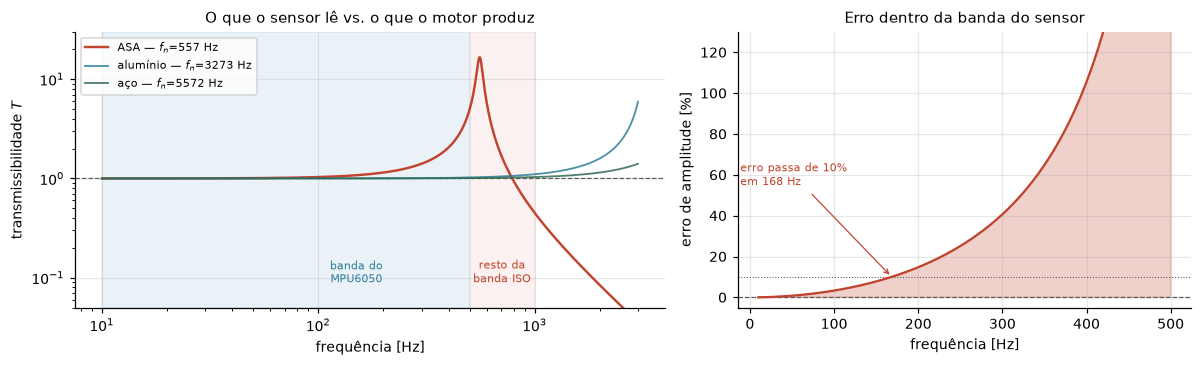

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios":[1.3,1]})

f = np.logspace(np.log10(10), np.log10(3000), 900)
ax = axes[0]
ax.axvspan(10, 500, color="#3182BD", alpha=0.10)
ax.axvspan(500, 1000, color=C_BAD, alpha=0.07)
ax.axhline(1, color=C_REF, ls="--", lw=0.8)
ax.plot(f, transmissibilidade(f, f_n), lw=1.6, color=C_BAD, label=f"ASA — $f_n$={f_n:.0f} Hz")

for nome, E, cor in [("alumínio", E_AL, C_OK), ("aço", E_ACO, "#2F6B4F")]:
    kb = k_placa_circular(H_BASE_EF, SPIGOT_D/2+13, E)
    ks = k_compressao(SPIGOT_D, SPIGOT_H, E)
    kc = k_viga_tubo(CORPO_EXT, PAREDE, ALTURA_TOTAL, E)
    fn_alt = (1/(2*np.pi))*np.sqrt(serie(kb,ks,kc)/MASSA)
    ax.plot(f, transmissibilidade(f, fn_alt), lw=1.2, color=cor, alpha=0.85,
            label=f"{nome} — $f_n$={fn_alt:.0f} Hz")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_ylim(0.05, 30)
ax.set_xlabel("frequência [Hz]"); ax.set_ylabel("transmissibilidade $T$")
ax.set_title("O que o sensor lê vs. o que o motor produz", fontsize=9.5)
ax.legend(fontsize=7.5, loc="upper left")
ax.text(150, 0.09, "banda do\nMPU6050", fontsize=7, color="#2E7D9A", ha="center")
ax.text(707, 0.09, "resto da\nbanda ISO", fontsize=7, color=C_BAD, ha="center")

# erro percentual dentro da banda util
ax = axes[1]
fb = np.linspace(10, 500, 400)
err = (transmissibilidade(fb, f_n) - 1)*100
ax.axhline(0, color=C_REF, ls="--", lw=0.8)
ax.axhline(10, color=C_REF, ls=":", lw=0.7)
ax.fill_between(fb, 0, err, color=C_BAD, alpha=0.25)
ax.plot(fb, err, lw=1.5, color=C_BAD)
ax.set_ylim(-5, 130)
ax.set_xlabel("frequência [Hz]"); ax.set_ylabel("erro de amplitude [%]")
ax.set_title("Erro dentro da banda do sensor", fontsize=9.5)
f10 = fb[np.argmax(err > 10)]
ax.annotate(f"erro passa de 10%\nem {f10:.0f} Hz", xy=(f10, 10), xytext=(f10-180, 55),
            fontsize=7.5, color=C_BAD,
            arrowprops=dict(arrowstyle="->", color=C_BAD, lw=0.8))
plt.tight_layout(); plt.show()

O painel da direita mostra o efeito prático: o erro de amplitude passa de 10% já em
**168 Hz** e cresce rápido até a ressonância. Toda medida acima disso vem inflada, e a
inflação **depende da frequência** — não é um ganho constante que se possa calibrar com
um único fator.

### Quanto disso é incerteza da estimativa?

O parâmetro menos confiável é a espessura efetiva da base, que o desenho não fixa
diretamente. Vale ver se a conclusão sobrevive à variação.

In [9]:
print(f"{'h base (mm)':>12} {'k (N/m)':>11} {'f_n (Hz)':>10}   dentro da banda ISO?")
print("-"*58)
for h in [4.0, 5.0, 6.0, 7.0, 9.0, 12.0]:
    kb = k_placa_circular(h, SPIGOT_D/2+13)
    kt = serie(kb, k_spigot, k_corpo)
    fn = (1/(2*np.pi))*np.sqrt(kt/MASSA)
    print(f"{h:>12.1f} {kt:>11.2e} {fn:>10.0f}   {'SIM' if fn < 1000 else 'não'}")

print("\nmesmo com base de 12 mm (o dobro do estimado), f_n continua abaixo")
print("dos 3 kHz exigidos pela regra de 3x. O corpo tubular de 78 mm limita.")

# quanto o corpo pesa nessa conta
print(f"\ncontribuição de cada elo para a flexibilidade total (1/k):")
tot = 1/k_base + 1/k_spigot + 1/k_corpo
for nome, k in [("base", k_base), ("spigot", k_spigot), ("corpo", k_corpo)]:
    print(f"  {nome:<8} {100*(1/k)/tot:>5.1f}%")

 h base (mm)     k (N/m)   f_n (Hz)   dentro da banda ISO?
----------------------------------------------------------
         4.0    6.53e+05        374   SIM
         5.0    1.05e+06        476   SIM
         6.0    1.45e+06        557   SIM
         7.0    1.78e+06        619   SIM
         9.0    2.26e+06        696   SIM
        12.0    2.62e+06        750   SIM

mesmo com base de 12 mm (o dobro do estimado), f_n continua abaixo
dos 3 kHz exigidos pela regra de 3x. O corpo tubular de 78 mm limita.

contribuição de cada elo para a flexibilidade total (1/k):
  base      51.1%
  spigot     0.4%
  corpo     48.5%


A decomposição mostra onde está o problema: base e corpo dividem quase toda a
flexibilidade, e o ressalto de centragem é irrelevante. Aumentar a espessura da base ajuda pouco
enquanto o corpo continuar sendo um tubo de 78 mm em ASA.

### O que domina: o material

Mantendo exatamente a mesma geometria e trocando só o material:

In [10]:
print(f"{'material':<12} {'E (GPa)':>8} {'k (N/m)':>11} {'f_n (Hz)':>10}  {'regra 3x ISO':>13}")
print("-"*62)
for nome, E in [("ASA (atual)", E_ASA), ("alumínio", E_AL), ("aço", E_ACO)]:
    kb = k_placa_circular(H_BASE_EF, SPIGOT_D/2+13, E)
    ks = k_compressao(SPIGOT_D, SPIGOT_H, E)
    kc = k_viga_tubo(CORPO_EXT, PAREDE, ALTURA_TOTAL, E)
    kt = serie(kb, ks, kc)
    fn = (1/(2*np.pi))*np.sqrt(kt/MASSA)
    ok = "atende" if fn >= 3000 else "não atende"
    print(f"{nome:<12} {E/1e9:>8.0f} {kt:>11.2e} {fn:>10.0f}  {ok:>13}")

print("\nA geometria não é o problema principal — o módulo do material é.")
print("Uma base metálica sozinha já mudaria a ordem de grandeza.")

material      E (GPa)     k (N/m)   f_n (Hz)   regra 3x ISO
--------------------------------------------------------------
ASA (atual)         2    1.45e+06        557     não atende
alumínio           69    4.99e+07       3273         atende
aço               200    1.45e+08       5572         atende

A geometria não é o problema principal — o módulo do material é.
Uma base metálica sozinha já mudaria a ordem de grandeza.


### Conclusão da §4

A frequência de montagem estimada, **cerca de 560 Hz**, cai dentro da banda que o
dispositivo pretende medir. Três consequências:

1. **Amplificação dependente da frequência.** Perto da ressonância o sensor lê várias
   vezes a vibração real. Como o fator varia com a frequência, não há calibração por
   ganho fixo que corrija.
2. **A rotulagem pela ISO 10816-3 fica comprometida.** A norma exige RMS de velocidade
   sobre 10–1000 Hz; se parte da banda vem amplificada e parte atenuada, o número
   resultante não corresponde ao da norma, mesmo com a integração implementada
   corretamente.
3. **Falsos positivos plausíveis.** Uma máquina saudável cuja excitação caia perto de
   560 Hz produziria leitura alta. Como a assinatura é estável e repetível, ela não
   parece ruído — parece defeito.

Vale notar que este efeito é **independente** da questão da banda do sensor discutida
antes. Mesmo trocando o MPU6050 por um acelerômetro de 20 kHz, o invólucro continuaria
filtrando o sinal antes que ele chegasse ao chip.

## Síntese

| Hipótese testada | Resultado | Veredito |
|---|---|---|
| A curvatura da carcaça compromete a fixação | perda de 11–21%; margem de ~2× sob vibração severa | **descartada** |
| As paredes ressoam na banda de medição | modo mais baixo ≈ 1,3 kHz, acima da banda ISO | **descartada** |
| O caminho até o sensor filtra o sinal | $f_n$ ≈ 560 Hz, dentro da banda; erro > 10% acima de 168 Hz | **confirmada** |

### Por que isto é um problema

O invólucro cumpre bem o que um invólucro normalmente precisa cumprir: proteger, vedar,
fixar e permitir manutenção. O problema aparece porque ele tem uma função adicional e
menos óbvia — **ser parte da cadeia de medição**. Nessa função, rigidez do caminho entre
a superfície medida e o sensor é requisito, e ASA tem módulo cem vezes menor que o do
aço.

O efeito é difícil de perceber porque não se manifesta como falha: o dispositivo liga, mede,
transmite e produz números plausíveis. Só que os números descrevem parcialmente o
invólucro, não o motor.

### Onde intervir

A decomposição da flexibilidade indica a ordem de eficácia:

1. **Base metálica** (alumínio usinado ou aço) mantendo a interface com o corpo. É o
   elo em contato direto com o motor e o de maior retorno por unidade de esforço.
2. **Aproximar o sensor da base.** Se o PCB do acelerômetro for montado sobre um pilar
   rígido solidário à base, em vez de suspenso no corpo, o caminho elástico encurta.
3. **Encurtar ou reforçar o corpo.** Os 78 mm de altura em tubo de parede fina
   respondem por parcela relevante da flexibilidade.

### Como verificar experimentalmente

A estimativa precisa de confirmação, e o ensaio é barato:

- **Teste de impacto (*bump test*).** Com o dispositivo montado no motor parado, dar um
  toque leve na tampa e registrar a resposta do próprio MPU6050. A frequência de
  decaimento livre é $f_n$. Confirma ou refuta esta seção em uma tarde.
- **Comparação com referência.** Medir o mesmo ponto com o Kaelix e com um acelerômetro
  de referência aparafusado. A razão entre os espectros é $T(f)$ medida.

### Limitações desta análise

Fórmulas fechadas com condições de contorno idealizadas; a rigidez real depende de
pré-carga dos parafusos, planicidade das faces impressas, orientação de camadas e
comportamento do inserto térmico. O módulo do ASA impresso é anisotrópico e varia com
infill e temperatura — a 80 °C pode cair sensivelmente, reduzindo ainda mais $f_n$. Os
valores devem ser lidos como ordem de grandeza; a conclusão qualitativa (a frequência de
montagem cai dentro da banda) é robusta à variação testada, mas o número exato não.